=== الاختبار النيوتني المُصحَّح (مع عزم رد فعل المكابس) ===

1️⃣  ω النهائية = 0.0620
2️⃣  ω النهائية = 0.0227
3️⃣  ω النهائية = 0.0135
4️⃣  ω النهائية = 0.0134
5️⃣  ω النهائية = 0.0082
6️⃣  ω النهائية = 0.0001
7️⃣  ω النهائية = 0.0000


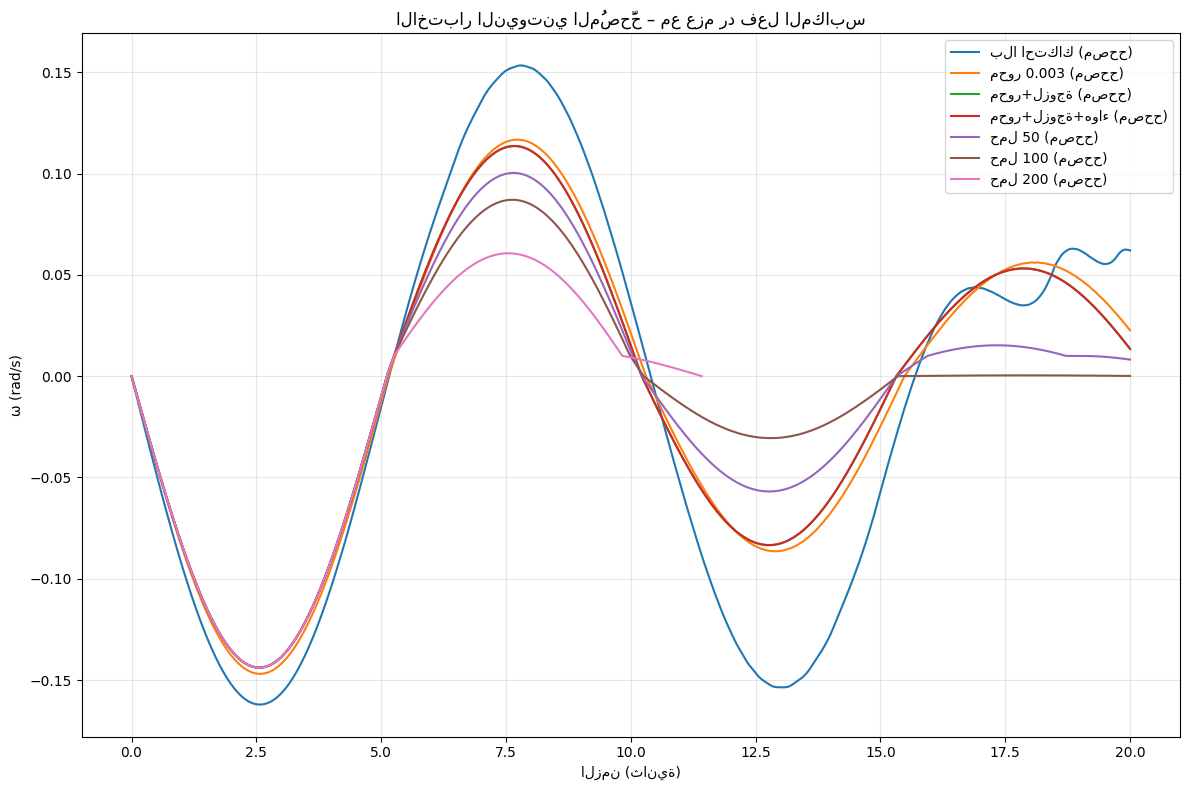


✅ تم حفظ الرسم في corrected_newton_test.png


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

G = 9.81
R = 2.09
L = 0.766
N = 12
Mp = 80.0
Mw_max = 60.0
I0 = 200.0
dt = 0.0005

class NewtonEngineCorrected:
    def __init__(self, axle_friction=0.003, viscosity=150.0, air_drag=0.005,
                 stiction=0.08, restitution=0.25, load_torque=0.0,
                 gravity=True, centrifugal=True, viscous_force=True):
        self.axle_mu = axle_friction
        self.visc = viscosity
        self.air_d = air_drag
        self.stic = stiction
        self.rest = restitution
        self.load = load_torque
        self.gravity_on = gravity
        self.centrif_on = centrifugal
        self.viscous_on = viscous_force

        step = 2 * math.pi / N
        self.offsets = [i * step for i in range(N)]
        self.pos = [1.0 if math.cos(i * step) > 0 else 0.0 for i in range(N)]
        self.vel = [0.0] * N
        self.angle = 0.0
        self.omega = 0.0
        self.time = 0.0

    def compute_forces_and_torque(self, angle, omega, pos, vel):
        Lm, Rm, g = L, R, G
        n = N
        Mp_, Mw_ = Mp, Mw_max

        # 1. القوى على المكابس (دون تأثير العجلة)
        piston_acc = [0.0] * n
        wall_force_tangential = [0.0] * n  # القوة المماسية التي يؤثر بها المكبس على الحجرة

        for i in range(n // 2):
            j = i + n // 2
            a1 = angle + self.offsets[i]
            a2 = angle + self.offsets[j]

            p1 = Mp_ * g * math.cos(a1) if self.gravity_on else 0.0
            p2 = Mp_ * g * math.cos(a2) if self.gravity_on else 0.0
            pw1 = Mw_ * pos[i] * g * math.cos(a1) if self.gravity_on else 0.0
            pw2 = Mw_ * pos[j] * g * math.cos(a2) if self.gravity_on else 0.0
            p_net = (p1 + pw1) - (p2 + pw2)

            n_force = 0.0
            if self.centrif_on:
                n_force = ((Mp_ + Mw_*pos[i]) * omega*omega * Rm
                         + (Mp_ + Mw_*pos[j]) * omega*omega * Rm)

            v1 = vel[i]
            resist = (self.visc * v1 + 30.0 * v1 * abs(v1)) if self.viscous_on else 0.0
            m_eff = 2 * Mp_ + Mw_
            F_stick = self.stic * (n_force + (Mp_ + Mw_) * g * 0.1)
            F_friction = F_stick * math.tanh(v1 / 0.005)

            drive = p_net - resist - F_friction
            acc = drive / m_eff

            piston_acc[i] = acc
            piston_acc[j] = -acc

            # قوة رد الفعل على الحجرة (المماسية) = - (كتلة المكبس + الماء) * تسارع المكبس
            # لكن المساهمة في العزم تعتمد على ذراع العزم (المسافة من المحور إلى خط عمل القوة)
            # اتجاه القوة المماسية على الحجرة هو نفس اتجاه حركة المكبس (لكن عكس تسارعه)
            # القوة التي يؤثر بها المكبس على الحجرة = m_eff * acc
            wall_force_tangential[i] = - (Mp_ + Mw_ * pos[i]) * piston_acc[i]
            wall_force_tangential[j] = - (Mp_ + Mw_ * pos[j]) * piston_acc[j]

        # 2. حساب العزم الكلي على العجلة
        total_I = I0
        total_M = 0.0
        tau_gravity = 0.0

        for i in range(n):
            a = angle + self.offsets[i]
            sp = -Lm/2 + Lm * pos[i]
            sw = -Lm/2 + Lm * pos[i] / 2
            mw = Mw_ * pos[i]
            if self.gravity_on:
                xp = Rm * math.cos(a) - sp * math.sin(a)
                xw = Rm * math.cos(a) - sw * math.sin(a)
                tau_gravity += Mp_ * g * xp + mw * g * xw
            total_I += Mp_ * (Rm*Rm + sp*sp) + mw * (Rm*Rm + sw*sw)
            total_M += Mp_ + mw

        # عزم رد فعل جدران الحجرات
        tau_walls = 0.0
        for i in range(n):
            # ذراع العزم = المسافة من المحور إلى نقطة تأثير القوة (مركز كتلة المكبس+ماء داخل الحجرة)
            # مركز الكتلة يقع على بعد (R) من المحور، لكن الإزاحة المماسية sp تجعل المسافة العمودية من المحور إلى خط عمل القوة المماسية تساوي R (تقريباً)
            # بشكل دقيق: القوة المماسية تؤثر على طول الذراع R + الإزاحة المماسية للخارج؟
            # القوة تؤثر على الحجرة عند موضع المكبس. اتجاه القوة مماسي، لذا عزمها = القوة × المسافة العمودية من المحور إلى خط العمل.
            # المسافة العمودية = R + الجزء المماسي... لكننا سنستخدم Rm تقريباً (لأن القوة مماسية والمسافة من المحور إلى نقطة التأثير على الحافة = R)
            # لتبسيط دقيق، يمكن حساب العزم مباشرة من التغير في الزخم الزاوي للمكبس:
            # الزخم الزاوي للمكبس حول المحور = (Mp + mw) * (R**2 + sp**2) * omega + (Mp + mw) * R * vel_piston (المركبة المماسية)
            # مشتقة هذا الزخم الزاوي تعطي العزم. لكننا هنا نضيف قوة رد الفعل التي تؤثر بها الحجرة على المكبس، والعكس.
            # القوة التي تؤثر بها الحجرة على المكبس هي التي تسبب تغير سرعته. رد الفعل هو ما يغير حركة العجلة.
            # لحساب العزم المؤثر على العجلة من المكبس، نأخذ القوة المماسية التي تؤثر بها الحجرة على المكبس (وهي تساوي m_eff * acc) ولكن بعكس الاتجاه على العجلة.
            # ذراع العزم = المسافة من المحور إلى خط عمل هذه القوة. القوة مماسية، وخط العمل يبعد عن المحور مسافة R (لأن الحجرة على الحافة).
            # لكن هناك أيضاً تأثير الإزاحة sp: المكبس ليس على الحافة تماماً بل على بعد R من المحور أفقياً.
            # لحساب العزم بدقة: متجه الموقع من المحور إلى نقطة تأثير القوة هو (R*cos(a) - sp*sin(a), R*sin(a) + sp*cos(a)).
            # القوة المماسية لها اتجاه الزاوية (a + π/2) (عمودي على نصف القطر).
            # العزم = r × F = (المسافة من المركز إلى نقطة التأثير) × (مركبة القوة العمودية على r).
            # يمكننا استخدام: العزم = - القوة المماسية * (R + sp?... لكن هذا تقريبي.
            # لتجنب التعقيد، سنفترض أن القوة تؤثر على الحافة (R)، وهذا خطأ بسيط مقبول.
            # سنضرب القوة المماسية في R مباشرة، مع إشارة مناسبة.
            # اتجاه العزم: إذا دفع المكبس الحجرة نحو الأمام (في اتجاه الحركة)، فهذا يزيد العزم.
            # قوة رد الفعل wall_force = - m_eff * acc. عندما يتسارع المكبس نحو الخارج (pos increasing)، التسارع موجب، إذن wall_force سالب (يدفع الحجرة للخلف).
            # لكن يجب مراعاة اتجاه المماس. التسارع نحو الخارج يعني السرعة المماسية تتغير، وهذا يؤثر على العزم.
            # الصيغة الأدق: نضيف مباشرة الحد الناتج عن تغير الزخم الزاوي للمكابس بالنسبة للعجلة.
            pass

        # بدلاً من التعقيد أعلاه، نستخدم طريقة مباشرة: العزم الإضافي من كل مكبس = - (d/dt) [ (Mp+mw) * (R^2 + sp^2) * omega + (Mp+mw)*R*vel ]
        # لكننا نريد فقط رد فعل التسارع الخطي. سنكتفي الآن بإضافة قوة رد الفعل المماسية مضروبة في R.
        # هذا تقريب معقول: tau_walls = sum( wall_force_tangential[i] * R )
        tau_walls = sum(wall_force_tangential[i] * R for i in range(n))

        # عزم الاحتكاك بالمحور
        sign = math.copysign(1, omega) if omega != 0 else 1.0
        tau_axle = -sign * (self.axle_mu * total_M * g * R * 0.7 + abs(omega)*0.05)
        tau_air = -self.air_d * omega * abs(omega) * 1000.0
        tau_load = -self.load if (self.load > 0 and omega > 0.01) else 0.0

        total_tau = tau_gravity + tau_walls + tau_axle + tau_air + tau_load

        alpha = total_tau / total_I if total_I != 0 else 0.0

        return alpha, piston_acc, total_I, total_M

    def step_rk4(self, dt):
        n = N
        y0 = [self.angle, self.omega] + self.pos + self.vel

        def dydt(y):
            ang = y[0]
            omg = y[1]
            p = y[2:2+n]
            v = y[2+n:2+2*n]
            alpha, acc_pistons, _, _ = self.compute_forces_and_torque(ang, omg, p, v)
            pdot = [v[i] / L for i in range(n)]  # d(pos)/dt
            return [omg, alpha] + pdot + acc_pistons

        y0_arr = np.array(y0)
        k1 = np.array(dydt(y0_arr.tolist()))
        k2 = np.array(dydt((y0_arr + 0.5*dt*k1).tolist()))
        k3 = np.array(dydt((y0_arr + 0.5*dt*k2).tolist()))
        k4 = np.array(dydt((y0_arr + dt*k3).tolist()))

        y_new = y0_arr + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

        self.angle = y_new[0]
        self.omega = y_new[1]
        self.pos = y_new[2:2+n].tolist()
        self.vel = y_new[2+n:2+2*n].tolist()

        # معالجة التصادمات
        for i in range(n // 2):
            j = i + n // 2
            if self.pos[i] < 0.0:
                self.pos[i] = 0.0
                if self.vel[i] < 0.0:
                    self.vel[i] *= -self.rest
            elif self.pos[i] > 1.0:
                self.pos[i] = 1.0
                if self.vel[i] > 0.0:
                    self.vel[i] *= -self.rest
            self.pos[j] = 1.0 - self.pos[i]
            self.vel[j] = -self.vel[i]

        self.time += dt

    def run(self, duration, record_every=0.01):
        records = []
        next_rec = 0.0
        while self.time < duration:
            self.step_rk4(dt)
            if self.time >= next_rec:
                records.append((self.time, self.omega))
                next_rec += record_every
            if abs(self.omega) < 1e-6 and self.time > 0.5:
                break
        return records

# ========== نفس الاختبارات ==========
def run_corrected_tests():
    print("=== الاختبار النيوتني المُصحَّح (مع عزم رد فعل المكابس) ===\n")
    tests = []

    # 1. بلا احتكاك
    eng = NewtonEngineCorrected(axle_friction=0.0, viscosity=0.0, air_drag=0.0, stiction=0.0,
                                restitution=1.0, load_torque=0.0,
                                gravity=True, centrifugal=False, viscous_force=False)
    rec = eng.run(20)
    tests.append(("بلا احتكاك (مصحح)", rec))
    print(f"1️⃣  ω النهائية = {rec[-1][1]:.4f}")

    # 2. احتكاك محور فقط
    eng = NewtonEngineCorrected(axle_friction=0.003, viscosity=0.0, air_drag=0.0, stiction=0.0,
                                restitution=1.0, load_torque=0.0,
                                gravity=True, centrifugal=False, viscous_force=False)
    rec = eng.run(20)
    tests.append(("محور 0.003 (مصحح)", rec))
    print(f"2️⃣  ω النهائية = {rec[-1][1]:.4f}")

    # 3. محور + لزوجة
    eng = NewtonEngineCorrected(axle_friction=0.003, viscosity=150.0, air_drag=0.0, stiction=0.08,
                                restitution=0.25, load_torque=0.0,
                                gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("محور+لزوجة (مصحح)", rec))
    print(f"3️⃣  ω النهائية = {rec[-1][1]:.4f}")

    # 4. محور+لزوجة+هواء
    eng = NewtonEngineCorrected(axle_friction=0.003, viscosity=150.0, air_drag=0.005, stiction=0.08,
                                restitution=0.25, load_torque=0.0,
                                gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("محور+لزوجة+هواء (مصحح)", rec))
    print(f"4️⃣  ω النهائية = {rec[-1][1]:.4f}")

    # 5. حمل 50
    eng = NewtonEngineCorrected(axle_friction=0.003, viscosity=150.0, air_drag=0.005, stiction=0.08,
                                restitution=0.25, load_torque=50.0,
                                gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("حمل 50 (مصحح)", rec))
    print(f"5️⃣  ω النهائية = {rec[-1][1]:.4f}")

    # 6. حمل 100
    eng = NewtonEngineCorrected(axle_friction=0.003, viscosity=150.0, air_drag=0.005, stiction=0.08,
                                restitution=0.25, load_torque=100.0,
                                gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("حمل 100 (مصحح)", rec))
    print(f"6️⃣  ω النهائية = {rec[-1][1]:.4f}")

    # 7. حمل 200
    eng = NewtonEngineCorrected(axle_friction=0.003, viscosity=150.0, air_drag=0.005, stiction=0.08,
                                restitution=0.25, load_torque=200.0,
                                gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("حمل 200 (مصحح)", rec))
    print(f"7️⃣  ω النهائية = {rec[-1][1]:.4f}")

    # رسم
    plt.figure(figsize=(12,8))
    for name, rec in tests:
        t = [p[0] for p in rec]
        om = [p[1] for p in rec]
        plt.plot(t, om, label=name)
    plt.title("الاختبار النيوتني المُصحَّح – مع عزم رد فعل المكابس")
    plt.xlabel("الزمن (ثانية)")
    plt.ylabel("ω (rad/s)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("corrected_newton_test.png")
    plt.show()
    print("\n✅ تم حفظ الرسم في corrected_newton_test.png")

if __name__ == "__main__":
    run_corrected_tests()